In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from Analysis import (
    dunn_posthoc_test,
    find_latest_experiment_csv,
    kruskal_wallis_test,
    load_experiment_data,
    pairwise_logrank_tests,
    plot_kaplan_meier,
    prepare_run_level_survival,
    summarize_survival_by_group,
)

csv_path = find_latest_experiment_csv(Path("."))
df = load_experiment_data(csv_path)

display(df.head())
print(f"Loaded {csv_path.name} with {len(df):,} rows and {df['RunId'].nunique():,} runs.")

missing_metrics = [column for column in ["Shannon Entropy", "Thermal Efficiency"] if column not in df.columns]
if missing_metrics:
    print("Missing advanced metrics in this CSV:", ", ".join(missing_metrics))
    print("Rerun the simulation after updating Model.py to populate them.")

,RunId,iteration,Step,width,height,n_food_clusters,food_area_percentage,food_base_quantity,num_agents,pheromone_decay_rate,...,Alive,Dead (Energy),Dead (Temperature),Deaths Foraging (Energy),Deaths Foraging (Temperature),Deaths Returning (Energy),Deaths Returning (Temperature),Deaths Resting (Energy),Deaths Resting (Temperature),Remaining Food (%)
0,3,3,0.0,60,60,12,0.15,10,45,0.055724,...,45,0,0,0,0,0,0,0,0,100.000000
1,3,3,1.0,60,60,12,0.15,10,45,0.055724,...,45,0,0,0,0,0,0,0,0,100.000000
2,3,3,2.0,60,60,12,0.15,10,45,0.055724,...,45,0,0,0,0,0,0,0,0,99.719052
3,3,3,3.0,60,60,12,0.15,10,45,0.055724,...,45,0,0,0,0,0,0,0,0,99.683933
4,3,3,4.0,60,60,12,0.15,10,45,0.055724,...,45,0,0,0,0,0,0,0,0,99.675154


Loaded swarm_foraging_experiment_optimized_20260504_180017.csv with 110,268 rows and 5 runs.
Missing advanced metrics in this CSV: Shannon Entropy, Thermal Efficiency
Rerun the simulation after updating Model.py to populate them.


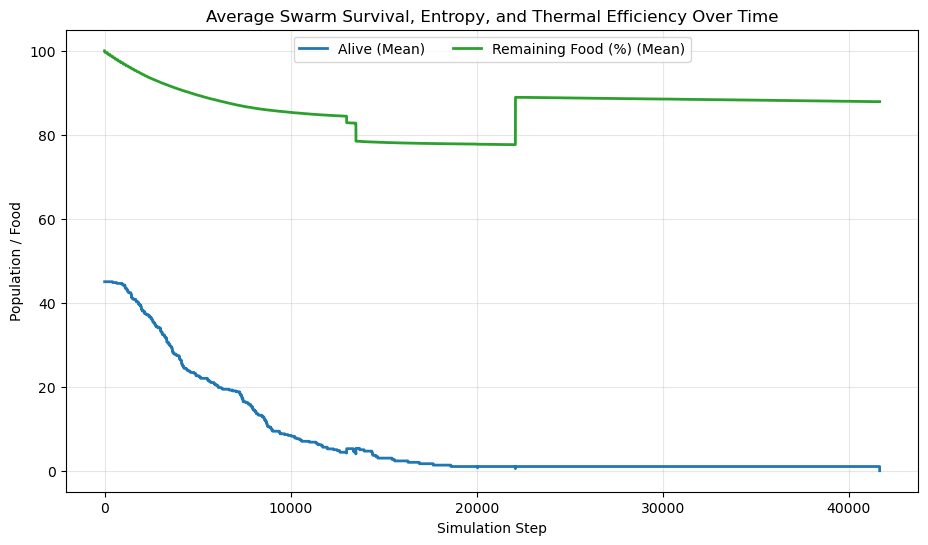

In [2]:
available_entropy = "Shannon Entropy" in df.columns
available_efficiency = "Thermal Efficiency" in df.columns

agg_spec = {
    "Alive": ("Alive", "mean"),
    "Remaining_Food": ("Remaining Food (%)", "mean"),
}
if available_entropy:
    agg_spec["Shannon_Entropy"] = ("Shannon Entropy", "mean")
if available_efficiency:
    agg_spec["Thermal_Efficiency"] = ("Thermal Efficiency", "mean")

overall = df.groupby("Step").agg(**agg_spec).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.plot(overall["Step"], overall["Alive"], label="Alive (Mean)", color="#1f77b4", linewidth=2)
ax1.plot(overall["Step"], overall["Remaining_Food"], label="Remaining Food (%) (Mean)", color="#2ca02c", linewidth=2)
ax1.set_xlabel("Simulation Step")
ax1.set_ylabel("Population / Food")
ax1.grid(True, alpha=0.3)

legend_handles, legend_labels = ax1.get_legend_handles_labels()
if available_entropy or available_efficiency:
    ax2 = ax1.twinx()
    if available_entropy:
        ax2.plot(overall["Step"], overall["Shannon_Entropy"], label="Shannon Entropy (Mean)", color="#d62728", linewidth=2, linestyle="--")
    if available_efficiency:
        ax2.plot(overall["Step"], overall["Thermal_Efficiency"], label="Thermal Efficiency (Mean)", color="#9467bd", linewidth=2, linestyle=":")
    ax2.set_ylabel("Entropy / Efficiency")
    handles_2, labels_2 = ax2.get_legend_handles_labels()
    legend_handles += handles_2
    legend_labels += labels_2

ax1.legend(legend_handles, legend_labels, loc="upper center", ncol=2)
ax1.set_title("Average Swarm Survival, Entropy, and Thermal Efficiency Over Time")
plt.show()

# Overall Swarm Status Over Time
This plot combines survival, food depletion, Shannon entropy, and thermal efficiency to show both the micro-level resource dynamics and the macro-level organization of the swarm.

# Survival and Significance Analysis
The next section converts the stepwise table into run-level survival data, fits Kaplan-Meier curves, and then applies rank-based tests to compare parameter settings.

In [3]:
comparison_candidates = ["num_agents", "pheromone_decay_rate"]
group_col = next((column for column in comparison_candidates if column in df.columns and df[column].nunique() > 1), None)

if group_col is None:
    print("No varying comparison column found in the loaded experiment table.")
else:
    run_level = prepare_run_level_survival(df, group_cols=(group_col,))
    display(summarize_survival_by_group(run_level, group_col))

    fig, ax, curves = plot_kaplan_meier(df, group_col=group_col)
    plt.show()

    if run_level[group_col].nunique() > 1:
        display(pairwise_logrank_tests(run_level, group_col))
    else:
        print(f"Only one {group_col!r} value is present, so pairwise log-rank tests are not applicable.")

No varying comparison column found in the loaded experiment table.


In [4]:
comparison_candidates = ["num_agents", "pheromone_decay_rate"]
group_col = next((column for column in comparison_candidates if column in df.columns and df[column].nunique() > 1), None)

if group_col is None:
    print("Statistical tests were skipped because no varying comparison column was found.")
else:
    run_level = prepare_run_level_survival(df, group_cols=(group_col,))

    aggregation_arguments = {group_col: (group_col, "first")}
    if "Shannon Entropy" in df.columns:
        aggregation_arguments["Mean Shannon Entropy"] = ("Shannon Entropy", "mean")
    if "Thermal Efficiency" in df.columns:
        aggregation_arguments["Mean Thermal Efficiency"] = ("Thermal Efficiency", "mean")

    per_run_metrics = (
        df.sort_values(["RunId", "Step"])
        .groupby("RunId")
        .agg(**aggregation_arguments)
        .reset_index()
    )

    comparison_tables = [("Run lifespan", run_level, "duration")]
    if "Mean Shannon Entropy" in per_run_metrics.columns:
        comparison_tables.append(("Mean Shannon Entropy", per_run_metrics, "Mean Shannon Entropy"))
    if "Mean Thermal Efficiency" in per_run_metrics.columns:
        comparison_tables.append(("Mean Thermal Efficiency", per_run_metrics, "Mean Thermal Efficiency"))

    for label, metric_frame, metric_name in comparison_tables:
        if metric_frame[group_col].nunique() < 2:
            continue

        statistic, p_value = kruskal_wallis_test(metric_frame, group_col, metric_name)
        print(f"{label}: Kruskal-Wallis H={statistic:.3f}, p={p_value:.5f}")
        if p_value < 0.05:
            display(dunn_posthoc_test(metric_frame, group_col, metric_name))

Statistical tests were skipped because no varying comparison column was found.
